## 概要

実習3_2です。与えられたデータを基に学習を深めてみましょう。

## 業務シナリオの紹介

あなたはある医療機関に勤務しており、乳癌（にゅうがん、英: Breast cancer）の検出を改善したいと考えています。

機械学習 (ML) を利用してこの問題を解決するのがあなたの課題です。このデータセットを使用して ML モデルのトレーニングを行い、患者に異常があるかどうかを予測します。

## このデータセットについて

breast_cancer.csv　は、Pythonのscikit-learn付属データセットに用意されており、ダウンロードしたデータです。

## 属性情報

PowerPointをご覧ください。
このデータセットの詳細については、 (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) を参照してください。

<font color="red">このステップは<u>データを機械学習に掛ける前処理的な段階</u>(データの特徴とかを調べる段階)</font>

## データのインポート

In [1]:
# 警告メッセージを無視するためにwarningsモジュールを使用
import warnings, requests, zipfile, io

# 警告メッセージを無視するフィルターを設定
warnings.simplefilter('ignore')

# データ処理のためにpandasモジュールをインポート
import pandas as pd

ModuleNotFoundError: No module named 'requests'

In [ ]:
# boto3を使ってAWSのサービスにアクセスするためのライブラリをインポート
!pip install boto3
import boto3

# pandasライブラリを使って、AWS S3上のCSVファイルを読み込む
# 事前に必要なデータをS3にアップロードをして、URIをメモしておいてください。
df = pd.read_csv('s3://machinelearning0655.s3.us-east-1.amazonaws.com/breast_cancer.csv') #これはクラウド
# df = pd.read_csv('breast_cancer.csv') #これはローカル

  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached s3transfer-0.17.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/15.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.0 MB 14.1 MB/s eta 0:00:02
   ----------- ---------------------------- 4.5/15.0 MB 10.7 MB/s eta 0:00:01
   ---------------------- ----------------- 8.4/15.0 MB 13.7 MB/s eta 0:00:01
   ------------------------------- -------- 11.8/15.0 MB 14.3 MB/s eta 0:00:01
   ---------------------------------- ----- 13.1/15.0 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------  14.7/15.0 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 15.0/15.0 MB 10.6 MB/s  0:00:01
Using cached jmespath-1.1.0-py3-none-any.whl (20 kB)
Using cached python_dateutil-2.9.0.post0-py2.py3-n


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\r_maruyama\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'boto3'

# ステップ 1: データの調査
まず、データセット内のデータを見ることから始めます。

このラボを最大限活用するために、セルを実行する前に、手順とコードを注意深くお読み
ください。慌てずに実験を進めましょう。

まず、**shape** を使って、行と列の数を調べます。

<font color="Red">まず項目が何個あってデータが何個あるのかdf.shapeを使って調べる</font>

In [ ]:
# DataFrameの行数と列数を確認するためにshape属性を使用
df.shape

次に、列のリストを得ます。<br>
<font color="red">どんな項目があるのか調べる</font>

In [ ]:
# DataFrameの列名を取得するためにcolumns属性を使用
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

30の特徴量と、ターゲット列の名前が *target* であることがわかります。

どのような列タイプがあるでしょうか?

<font color="red">各項目のデータ型を調べる</font>

In [ ]:
# DataFrameの各列のデータ型を確認するためにdtypes属性を使用
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

特徴量には30の浮動小数がありますが、ターゲットは int です。

最初の列の統計を調べるには、**describe** 関数を使用できます。

<font color="red">例としてmean radiusの情報を引き出す<br>何回出てくるのか、最小値、最大値、etc...</font>

In [ ]:
# 特定の列（'mean radius'）の統計的な要約を取得するためにdescribeメソッドを使用
df['mean radius'].describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64

このデータセットには 30の特徴量がありますが、DataFrame 全体で **describe ** を実行することで、各特徴量の統計を表示できます。

<font color="red">さっきのコマンドは一つの項目に対してだけの情報しか引き出せなかったけど<br>このコマンドは表形式で全項目の情報を引き出せる</font>

In [ ]:
# DataFrame全体の統計的な要約を取得するためにdescribeメソッドを使用
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**質問:** よく分散されていない特徴量はありますか? 調べたい外れ値を持つ特徴量はありますか? 特徴量間に相関関係があるように見えますか?

数値を見るだけでは観察が難しい場合があるため、これらの値をプロットすることにします。

<font color="red">何をしてるのか↓<br>外れ値を探すために数値だけを見比べて探すのは面倒くさいからグラフを使って外れ値を探す</font>

<Axes: >

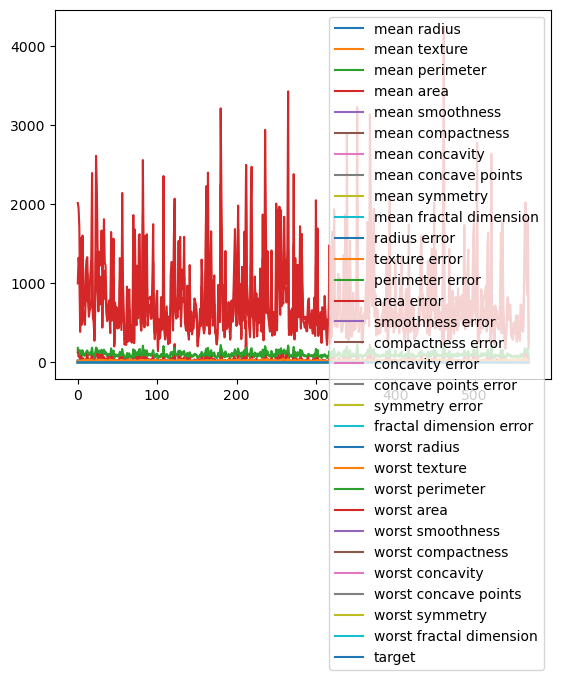

In [ ]:
# データの可視化のためにmatplotlib.pyplotモジュールをインポート
import matplotlib.pyplot as plt

# Jupyter Notebook上でプロットを表示するために%matplotlib inlineを使用
%matplotlib inline

# DataFrameの全体的なプロットを生成するためにplotメソッドを使用
df.plot()

これでは、イメージがつきませんね。
ここで、*密度またはカーネル密度推定 (KDE) プロット* を使用して、各特徴量の値の分布をプロットします。

<font color="red">さっきのグラフだけだったら全部の項目が混ざって各項目の外れ値を探すのが難しいから項目に分けて外れ値を探す</font>

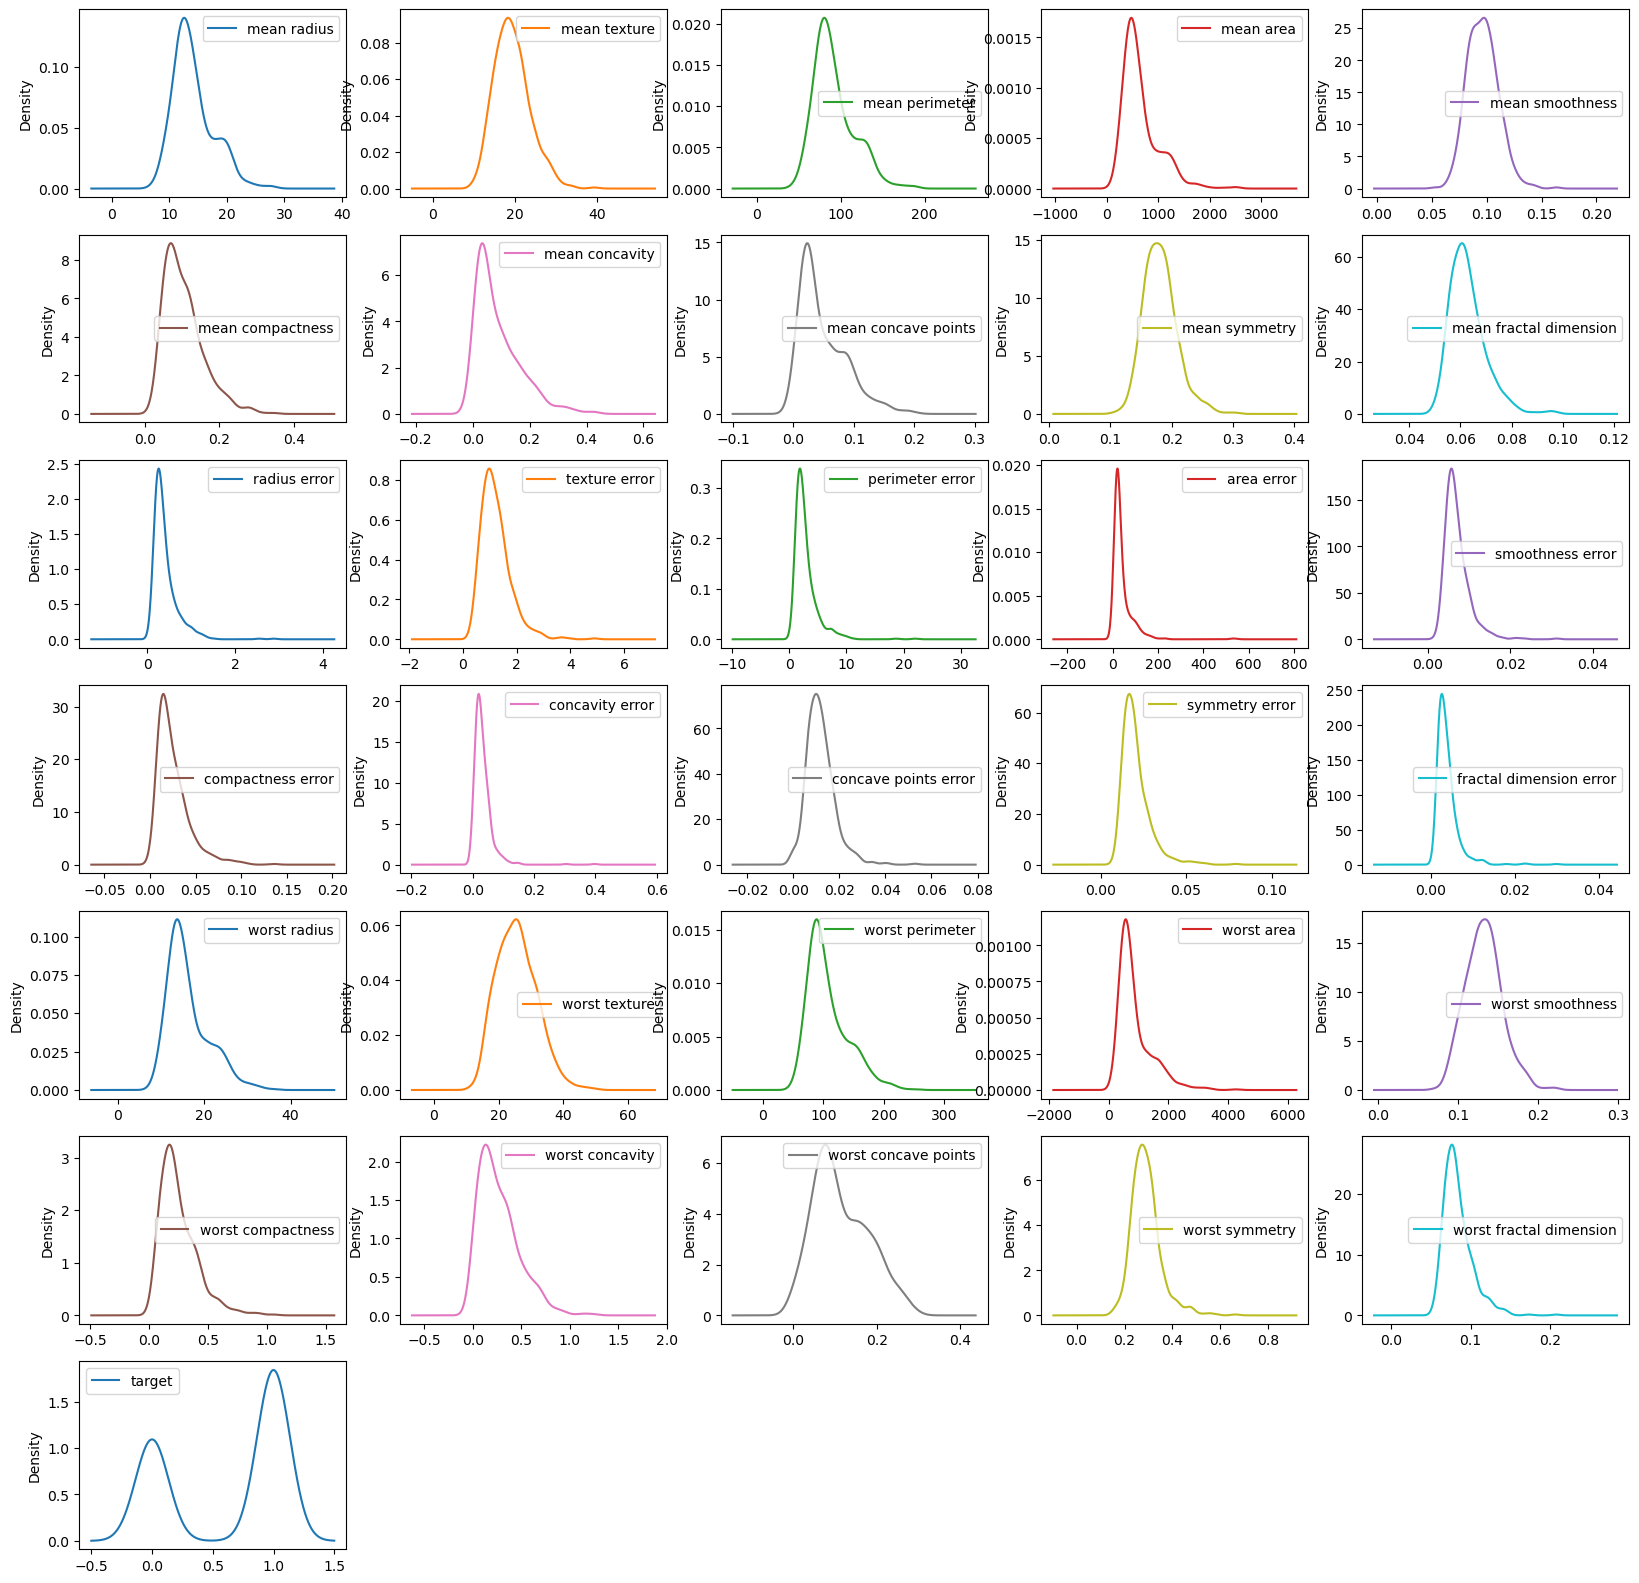

In [ ]:
# 密度プロットを生成するためにplotメソッドを使用し、subplotsをTrueに設定
# layoutでプロットの配置を指定し、figsizeでプロットのサイズを設定
# sharexをFalseに設定してx軸を共有しないようにする
df.plot(kind='density', subplots=True, layout=(7, 5), figsize=(20, 20), sharex=False)

# プロットを表示
plt.show()

目立つプロット図はありますか?

### mean area の調査
次に、**mean area** を調査します。

*密度プロット* から始めます。これを再現すると、*値の分布* が表示されます。

<font color="red">さっきのグラフから見る感じ「eman area」に外れ値がありそうだからmean areaだけに絞ってグラフを出力する</font>

<Axes: ylabel='Density'>

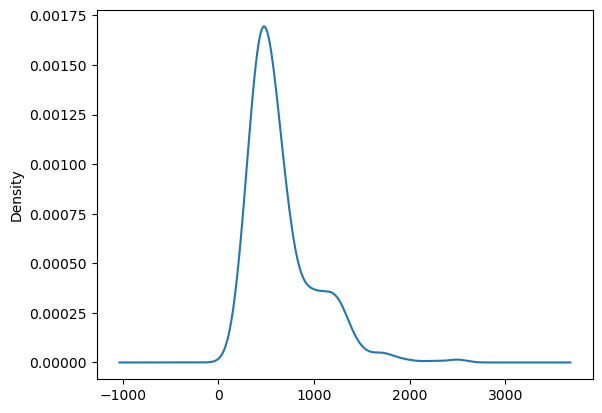

In [ ]:
# 特定の列（'mean area'）に対して密度プロットを生成するためにplot.density()メソッドを使用
df['mean area'].plot.density()

密度プロットにより、滑らかな曲線になります。**2500** の周辺で数値が増加していそうなことがわかります。*ヒストグラム* でデータを視覚化します。

<font color="red">もっと見やすくするためにヒストグラムで可視化する</font>

<Axes: ylabel='Frequency'>

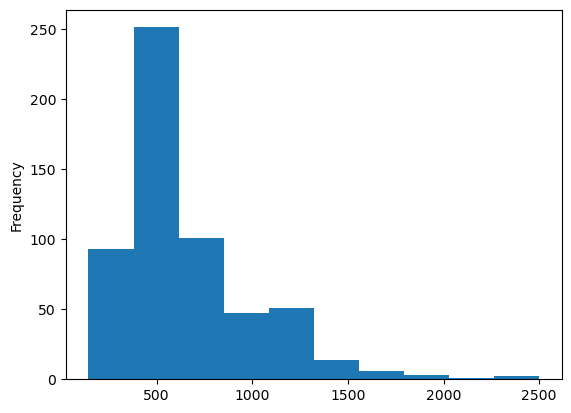

In [ ]:
# 特定の列（'mean area'）に対してヒストグラムを生成するためにplot.histメソッドを使用
df['mean area'].plot.hist()

<font color="red">箱ひげ図も活用する</font>

<Axes: >

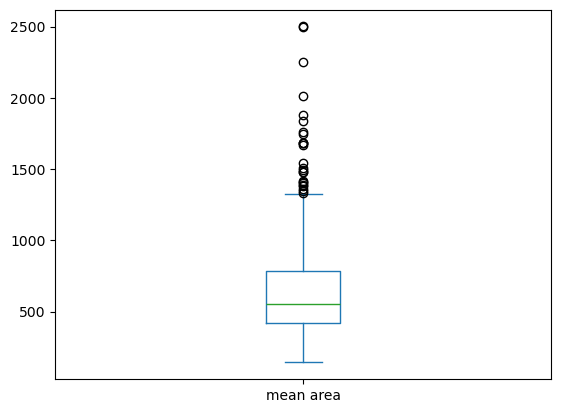

In [ ]:
# 特定の列（'mean area'）の箱ひげ図を生成するためにplotメソッドを使用
df['mean area'].plot.box()

**2500** の周辺に微増を確認できます。このような外れ値によって、トレーニングモデルに狂いが生じることがあります。唯一の確認方法は、外れ値がある場合とない場合の両方でモデルのテストを行い、モデルのスコアを比較することです。今回は大きく外れているわけではないのでそのままでも問題ないです。

ボックスプロットを確認すると、最大値*と見られる*数値の上にクラスターがあるように見えます。これらのデータポイントとターゲットの間に相関関係がありますか?

相関関係を探す前に、ターゲットをさらに調べます。

### ターゲットの分析

まず、どのような分布があるでしょうか?

In [ ]:
# 特定の列（'target'列）の各値の出現回数を取得するためにvalue_countsメソッドを使用
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

<font color="red">コマンドの実行結果↓<br>
| 1(陰性) | 0(陽性) |
|  :---: |  :---: |
| 357件 | 212件 |
</font>

<u color="red">2/3 が *良性*</u>、<u>1/3* が *悪性*</u> のようです。この結果に問題はないはずですが、より多くのデータを得られれば、数値をより多く試し、また評価できます。

今回は、クラス値ではなくintですので、マッパーを使用する必要はありません。

ターゲットに対して *mean area* をプロットできます。

<font color="red">良性か悪性かに分けて分けるどれだけ値が分かれてるか調べる</font>

<Axes: xlabel='target', ylabel='mean area'>

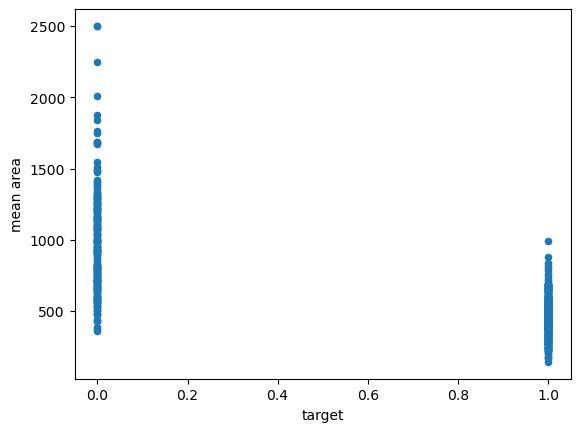

In [ ]:
# 散布図を生成するためにplot.scatterメソッドを使用
# y軸に'mean area'列、x軸に'target'列を指定
df.plot.scatter(y='mean area', x='target')

どんなことがわかるでしょうか?

高い値と異常の間には相関があるように見えますが、同じ範囲にある値も多数あります。したがって、相関関係がある可能性はありますが、データをより詳しく見る価値があります。

**チャレンジ課題:** 前のセルを使用して、他の特徴量の値がどのようにターゲットに対応しているかを判断します。

### 複数変数の可視化

これまでのステップで明らかになったように、視覚化は非常に有効です。ときには、複数のデータポイントを分析したいことがあります。*groupby* を使用すれば、これを実行できます。

*異常* と *正常* の両方の値についての特徴量を並べてプロットすると、他の違いを確認できることがあります。

0         Axes(0.1,0.15;0.363636x0.75)
1    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

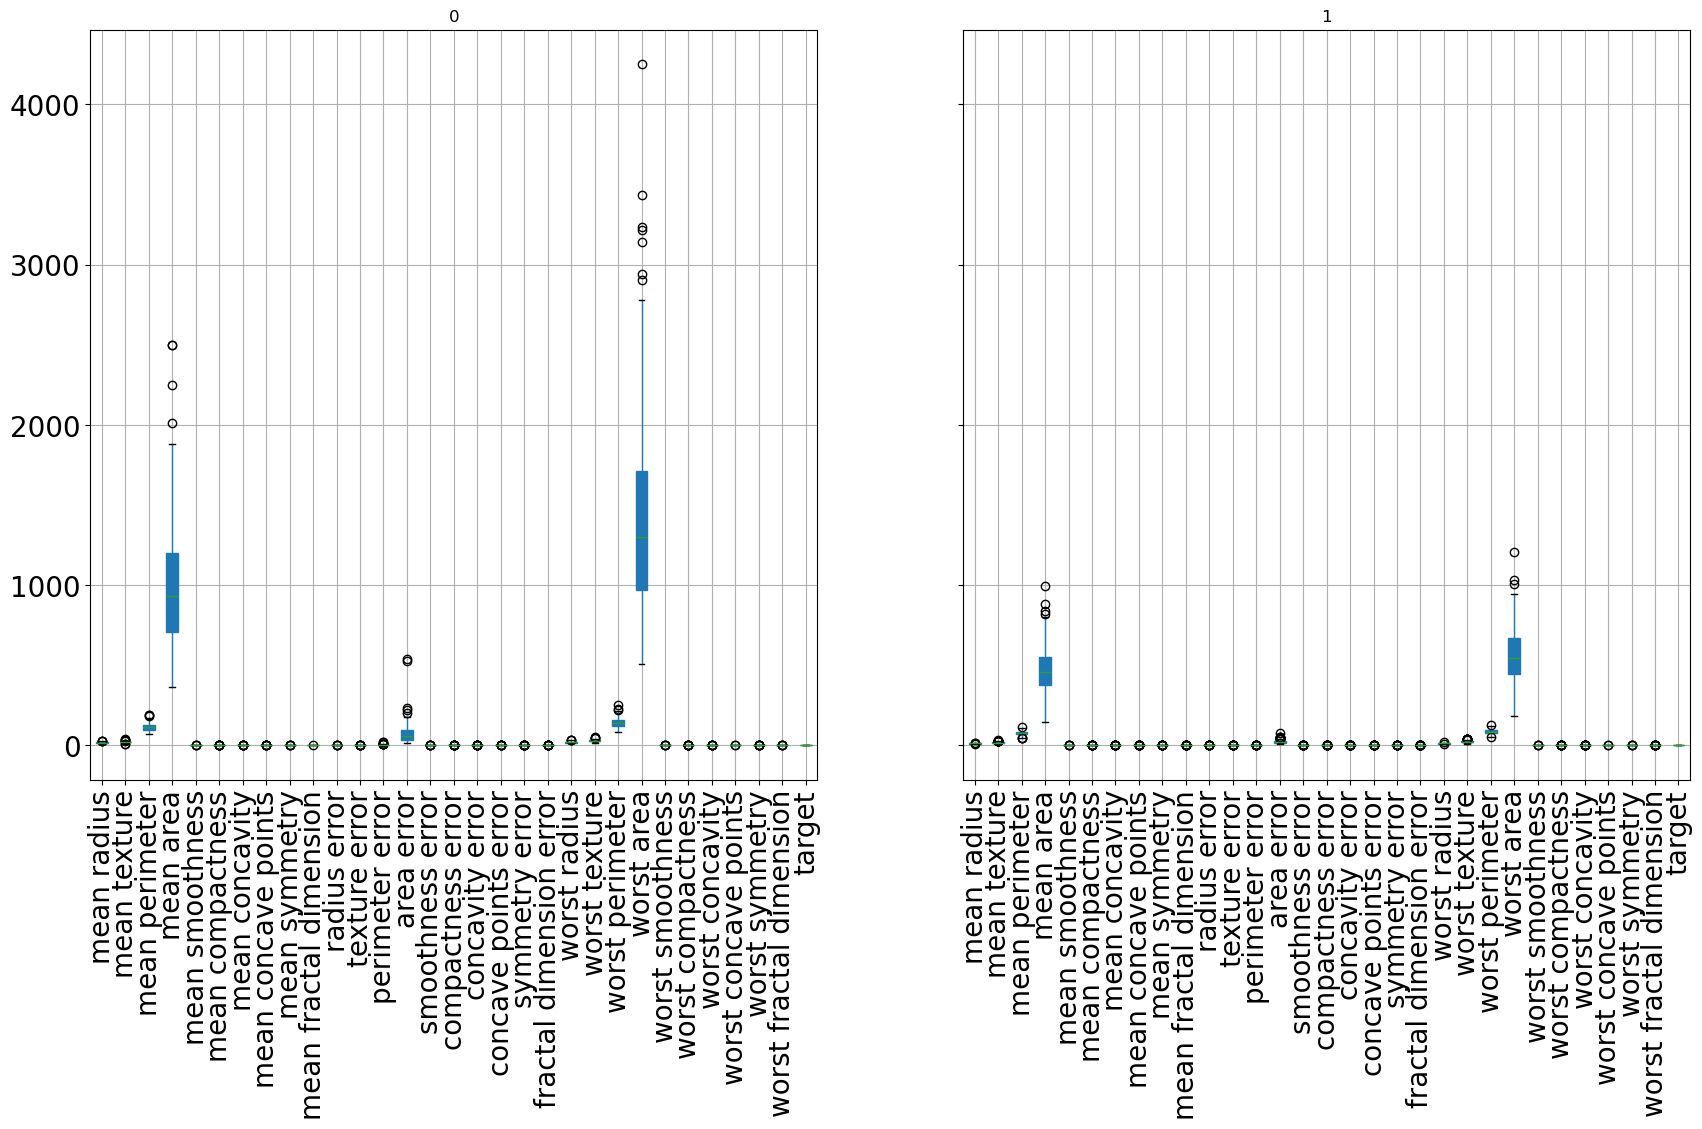

In [15]:
# 'target'列でグループ分けして、各グループのボックスプロットを生成
# fontsizeでフォントサイズを指定し、rotでx軸のラベルを回転させる角度を指定
# figsizeでプロットのサイズを指定し、patch_artistをTrueに設定してボックスの塗りつぶしを有効にする


**corr** 関数を使用すると、データセット全体に対して相関行列を作成できます。

In [ ]:
# 'target'列でグループ分けして、各グループのボックスプロットを生成
# fontsizeでフォントサイズを指定し、rotでx軸のラベルを回転させる角度を指定
# figsizeでプロットのサイズを指定し、patch_artistをTrueに設定してボックスの塗りつぶしを有効にする
df.groupby('target').boxplot(fontsize=20, rot=90, figsize=(20, 10), patch_artist=True)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

このデータをプロットすることもできます。
これには少し時間がかかります。

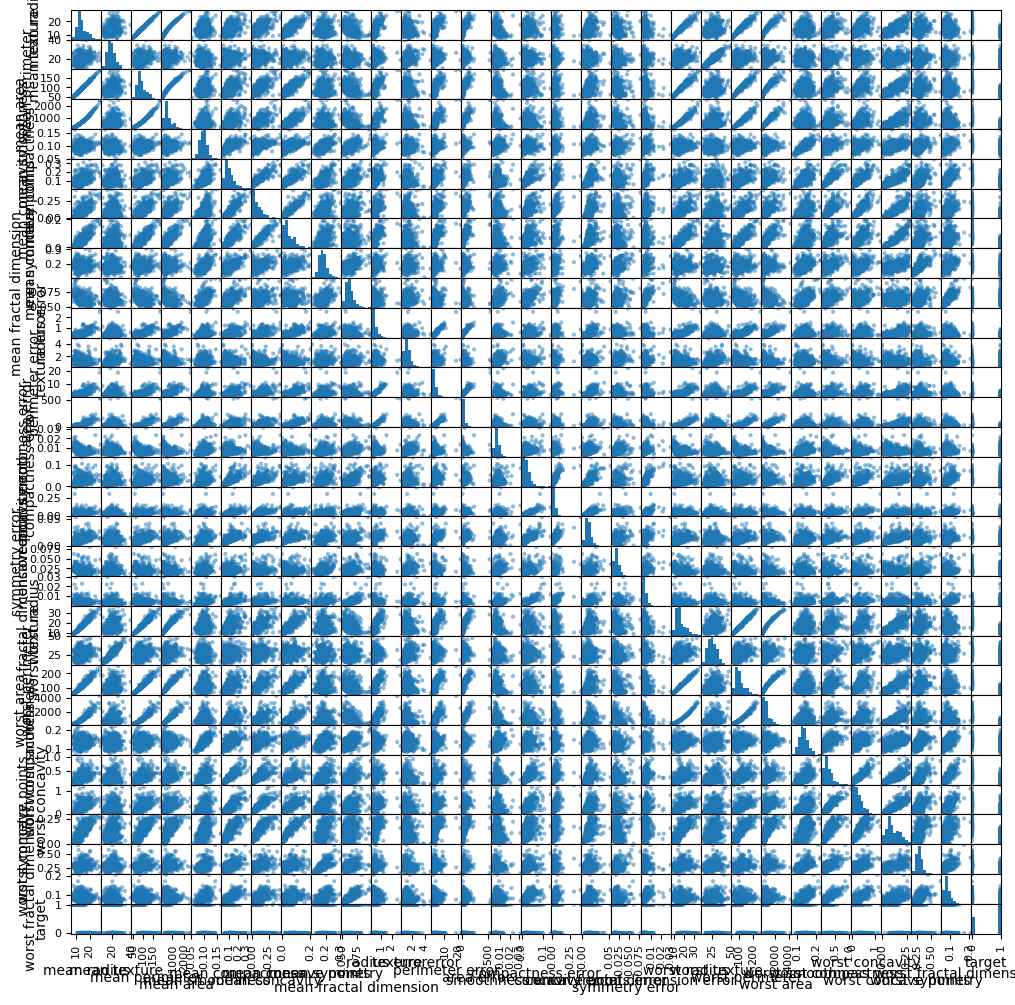

In [ ]:
# 散布図行列を生成するためにpandas.plotting.scatter_matrix関数を使用
# figsizeでプロットのサイズを設定
pd.plotting.scatter_matrix(df, figsize=(12, 12))

# プロットを表示
plt.show()

今回は特徴量が多いので少し分かり辛いですね。
**seaborn** を使用すると、**ヒートマップ* として相関関係を可視化できます。

<Axes: >

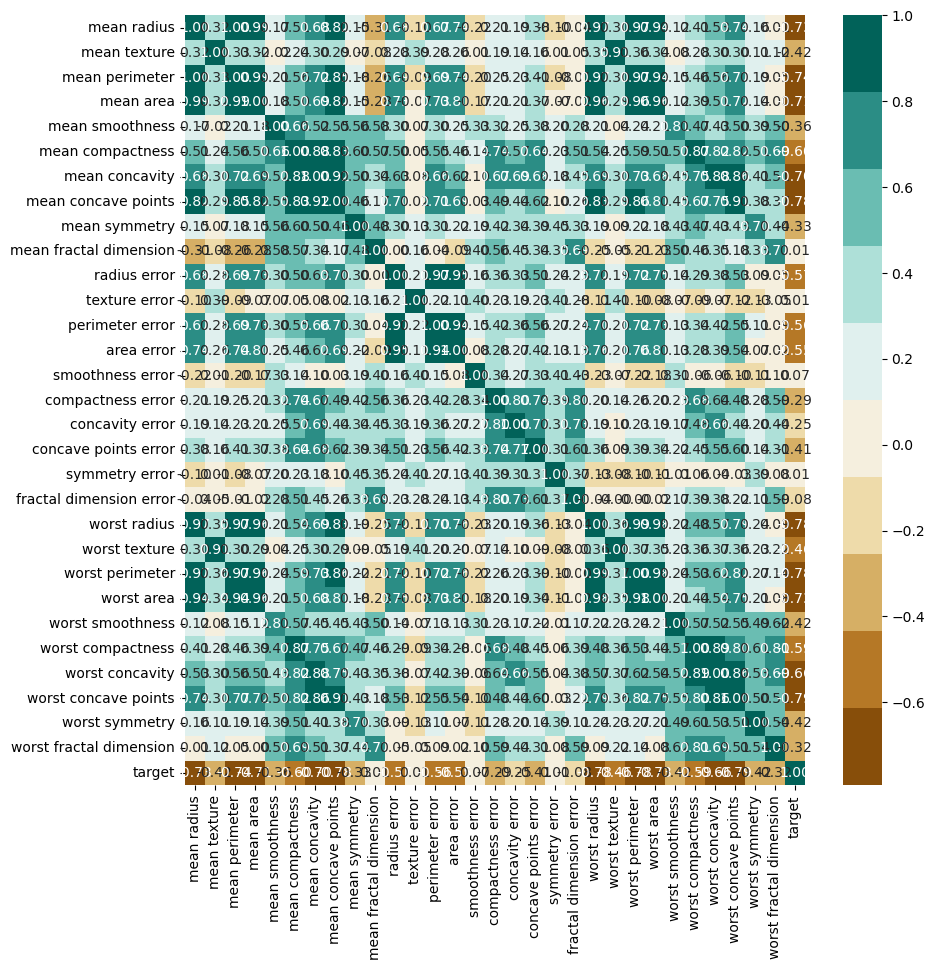

In [ ]:
# データの可視化のためにseabornモジュールをインポート
import seaborn as sns

# プロットのサイズを指定するためにsubplotsを使用
fig, ax = plt.subplots(figsize=(10, 10))

# カラーマップを生成するためにcolor_paletteメソッドを使用
colormap = sns.color_palette("BrBG", 10)

# 相関行列のヒートマップを生成し、アノテーションを表示する
sns.heatmap(corr_matrix, cmap=colormap, annot=True, fmt=".2f")

# お疲れ様でした。

#お疲れ様でした。

今回は、メソッドの確認がメインでしのたで、ラボと同様なメソッドを使いながら作業をしました。


## まとめ
このセクションは**機械学習のモデルを作る前に、どんなデータを使うのかを理解する**セクション。ここを理解しないと機械学習のモデルを作った時にAIの精度がわるくなったりするからやらないといけない

